# SIP Project — Complete Pipeline
### Single Model | Ensemble | Validation Accuracy Graphs | Test Image Comparison
---

In [1]:
# CELL 1 - loading libraries
import os
import re
import zipfile
import pickle
import shutil
import numpy as np
import matplotlib.pyplot as plt
import torch
from torch.utils.data import Dataset, DataLoader
from PIL import Image

print('All imports successful.')


All imports successful.


In [ ]:
# CELL 2 - GLOBAL CONFIG
# This version can use your local sip_dataset.zip or an already-extracted dataset.

SEED = 42
torch.manual_seed(SEED)
np.random.seed(SEED)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print('Using device:', device)

IMAGE_DIR = '/kaggle/input/datasets/kajalkumari1234/satellite-dataset/all/images'
MASK_DIR  = '/kaggle/input/datasets/kajalkumari1234/satellite-dataset/all/masks'

# Hold out complete image/mask pairs before training.
# These test images are never used for training or validation.
TEST_SPLIT = 0.10
VAL_SPLIT  = 0.20

# Optional: copy the held-out test images/masks into this output folder so the
# unknown test set is easy to inspect and reuse later.
COPY_TEST_SPLIT_TO_FOLDER = True
TEST_OUTPUT_DIR = '/kaggle/working/heldout_test_split'

# Hyper-parameters tuned for this project question:
# single NN baseline + NN ensemble with different hidden layers/nodes.
IMAGE_SIZE          = (256, 256)
EPOCHS              = 15
LR                  = 0.0015
LR_DECAY            = 0.90
WEIGHT_DECAY        = 1e-4
GRAD_CLIP           = 5.0
MINI_BATCH_SIZE     = 16384
MAX_MASKS_SCAN      = None     # None scans all masks so no class colour is missed
CLASS_WEIGHT_POWER  = 0.5      # helps rare land-cover classes without over-correcting


Using device: cuda


In [3]:
# CELL 3 - COLOUR MAPPING
# Scans masks and assigns a unique integer to every RGB colour.
# build_lookup_table() creates a fast 256^3 tensor for decoding.

def _file_number(filename):
    nums = re.findall(r'\d+', filename)
    return int(nums[-1]) if nums else -1


def build_color_mapping(mask_dir, max_masks=None):
    """Scan mask files and build colour <-> label dictionaries."""
    color_to_label = {}
    label_to_color = {}
    label = 0

    files = sorted(os.listdir(mask_dir), key=_file_number)
    if max_masks is not None:
        files = files[:max_masks]

    for file in files:
        mask = np.array(Image.open(os.path.join(mask_dir, file)).convert('RGB'))
        for c in np.unique(mask.reshape(-1, 3), axis=0):
            c = tuple(c.tolist())
            if c not in color_to_label:
                color_to_label[c] = label
                label_to_color[label] = c
                label += 1
    return color_to_label, label_to_color


def build_lookup_table(color_to_label):
    """Returns a 256x256x256 tensor: lut[R,G,B] = class label."""
    lut = torch.full((256, 256, 256), -1, dtype=torch.long)
    for (r, g, b), label in color_to_label.items():
        lut[r, g, b] = label
    return lut


print('Building colour mapping ...')
color_to_label, label_to_color = build_color_mapping(MASK_DIR, max_masks=MAX_MASKS_SCAN)
lut = build_lookup_table(color_to_label)
NUM_CLASSES = len(color_to_label)
print(f'Found {NUM_CLASSES} unique classes.')


Building colour mapping ...
Found 7 unique classes.


In [ ]:
# CELL 4 - DATASET
# Each sample = pixel subset from one image.
# X : (N, 3) normalised RGB
# y : (N,) integer class labels via LUT

def get_matching_pairs(image_dir, mask_dir):
    """Return matched image/mask filenames by shared number in the filename."""
    image_files = sorted(os.listdir(image_dir), key=_file_number)
    mask_files = sorted(os.listdir(mask_dir), key=_file_number)

    image_by_num = {_file_number(f): f for f in image_files}
    mask_by_num = {_file_number(f): f for f in mask_files}
    common_ids = sorted(set(image_by_num) & set(mask_by_num))

    pairs = [
        {'id': i, 'image_file': image_by_num[i], 'mask_file': mask_by_num[i]}
        for i in common_ids
    ]
    if len(pairs) == 0:
        raise ValueError('No matching image/mask pairs found. Check IMAGE_DIR and MASK_DIR.')
    return pairs


class PixelDataset(Dataset):
    def __init__(self, image_dir, mask_dir, color_to_label, lut,
                  pairs=None):
        self.image_dir = image_dir
        self.mask_dir = mask_dir
        self.color_to_label = color_to_label
        self.lut = lut
        self.pairs = pairs if pairs is not None else get_matching_pairs(image_dir, mask_dir)

    def __len__(self):
        return len(self.pairs)

    def __getitem__(self, idx):
        pair = self.pairs[idx]
        img = np.array(
            Image.open(os.path.join(self.image_dir, pair['image_file']))
                 .convert('RGB').resize(IMAGE_SIZE, Image.BILINEAR)
        ) / 255.0

        mask = np.array(
            Image.open(os.path.join(self.mask_dir, pair['mask_file']))
                 .convert('RGB').resize(IMAGE_SIZE, Image.NEAREST)
        )

        pixels = torch.tensor(img.reshape(-1, 3), dtype=torch.float32)
        mask_t = torch.from_numpy(mask).long()
        labels = self.lut[mask_t[..., 0], mask_t[..., 1], mask_t[..., 2]].view(-1)

        valid = labels >= 0
        pixels = pixels[valid]
        labels = labels[valid]

        return pixels, labels


all_pairs = get_matching_pairs(IMAGE_DIR, MASK_DIR)
print(f'Dataset size: {len(all_pairs)} matched image/mask pairs')


Dataset size: 203 matched image/mask pairs


In [ ]:
# CELL 5 - TRAIN / VALIDATION / TEST SPLIT
# The split is done by complete image/mask pair, not by pixels.
# This keeps test images unknown to the model during training.

def split_pairs(pairs, test_split=0.10, val_split=0.20, seed=42):
    rng = np.random.default_rng(seed)
    order = rng.permutation(len(pairs))

    test_size = max(1, int(round(test_split * len(pairs))))
    test_idx = order[:test_size]
    remaining_idx = order[test_size:]

    val_size = max(1, int(round(val_split * len(remaining_idx))))
    val_idx = remaining_idx[:val_size]
    train_idx = remaining_idx[val_size:]

    train_pairs = [pairs[i] for i in train_idx]
    val_pairs = [pairs[i] for i in val_idx]
    test_pairs = [pairs[i] for i in test_idx]
    return train_pairs, val_pairs, test_pairs


def copy_test_split_to_folder(test_pairs, image_dir, mask_dir, output_dir):
    image_out = os.path.join(output_dir, 'images')
    mask_out = os.path.join(output_dir, 'masks')
    os.makedirs(image_out, exist_ok=True)
    os.makedirs(mask_out, exist_ok=True)

    for pair in test_pairs:
        shutil.copy2(os.path.join(image_dir, pair['image_file']),
                     os.path.join(image_out, pair['image_file']))
        shutil.copy2(os.path.join(mask_dir, pair['mask_file']),
                     os.path.join(mask_out, pair['mask_file']))

    return image_out, mask_out


train_pairs, val_pairs, test_pairs = split_pairs(
    all_pairs,
    test_split=TEST_SPLIT,
    val_split=VAL_SPLIT,
    seed=SEED
)

train_dataset = PixelDataset(IMAGE_DIR, MASK_DIR, color_to_label, lut,
                              pairs=train_pairs)
val_dataset = PixelDataset(IMAGE_DIR, MASK_DIR, color_to_label, lut,
                            pairs=val_pairs)
test_dataset = PixelDataset(IMAGE_DIR, MASK_DIR, color_to_label, lut,
                         pairs=test_pairs)

train_loader = DataLoader(train_dataset, batch_size=1, shuffle=True)
val_loader   = DataLoader(val_dataset,   batch_size=1, shuffle=False)
test_loader  = DataLoader(test_dataset,  batch_size=1, shuffle=False)

print(f'Train: {len(train_pairs)} images  |  Val: {len(val_pairs)} images  |  Test: {len(test_pairs)} images')

if COPY_TEST_SPLIT_TO_FOLDER:
    TEST_IMAGE_DIR, TEST_MASK_DIR = copy_test_split_to_folder(
        test_pairs, IMAGE_DIR, MASK_DIR, TEST_OUTPUT_DIR
    )
    print('Held-out test images copied to:', TEST_IMAGE_DIR)
    print('Held-out test masks copied to :', TEST_MASK_DIR)
else:
    TEST_IMAGE_DIR, TEST_MASK_DIR = IMAGE_DIR, MASK_DIR
    print('Held-out test files were not copied. Paths will point to the original dataset folders.')

print('First held-out test pair:', test_pairs[0])


Train: 146 images  |  Val: 37 images  |  Test: 20 images
Held-out test images copied to: /kaggle/working/heldout_test_split/images
Held-out test masks copied to : /kaggle/working/heldout_test_split/masks
First held-out test pair: {'id': 154, 'image_file': 'image0154.jpg', 'mask_file': 'mask0154.png'}


In [6]:
# CELL 6 - MLP PRIMITIVES  (built from scratch, no nn.Module)
# Hidden layers use ReLU. The output layer returns logits for stable training;
# softmax is applied only for probability display/prediction.

def init_mlp(layer_sizes):
    params = []
    for i in range(len(layer_sizes) - 1):
        std = (2.0 / layer_sizes[i]) ** 0.5
        W = torch.randn(layer_sizes[i], layer_sizes[i+1], device=device) * std
        W.requires_grad_(True)
        b = torch.zeros(1, layer_sizes[i+1], device=device)
        b.requires_grad_(True)
        params.append([W, b])
    return params


def relu(x):
    return torch.clamp(x, min=0)


def forward_logits(X, params):
    A = X
    for i, (W, b) in enumerate(params):
        Z = A @ W + b
        A = Z if i == len(params) - 1 else relu(Z)
    return A


def forward(X, params):
    return torch.softmax(forward_logits(X, params), dim=1)


def cross_entropy_from_logits(logits, y, class_weights=None):
    log_probs = logits - torch.logsumexp(logits, dim=1, keepdim=True)
    losses = -log_probs[torch.arange(len(y), device=y.device), y]
    if class_weights is not None:
        losses = losses * class_weights[y]
    return losses.mean()


print('MLP primitives ready (ReLU hidden layers + stable logits).')


MLP primitives ready (ReLU hidden layers + stable logits).


In [7]:
# CELL 7 - TRAINING FUNCTION
# Accuracy improvements:
#   1. Adam-style optimiser from scratch for faster, steadier convergence
#   2. Weighted cross-entropy to reduce rare-class neglect
#   3. Gradient clipping + LR decay + light weight decay

def estimate_class_weights(loader, num_classes, power=0.5):
    counts = torch.zeros(num_classes, dtype=torch.float64)
    for _, y in loader:
        y = y.squeeze(0)
        counts += torch.bincount(y[y >= 0], minlength=num_classes).double()

    counts = torch.clamp(counts, min=1.0)
    weights = (counts.sum() / counts).pow(power)
    weights = weights / weights.mean()
    return weights.float().to(device)


CLASS_WEIGHTS = estimate_class_weights(train_loader, NUM_CLASSES, CLASS_WEIGHT_POWER)
print('Class weights:', [round(float(w), 3) for w in CLASS_WEIGHTS.cpu()])


def val_accuracy_single(params, loader):
    """Pixel accuracy of one model on the given loader."""
    correct = total = 0
    for X, y in loader:
        X = X.squeeze(0).to(device)
        y = y.squeeze(0).to(device)
        with torch.no_grad():
            pred = torch.argmax(forward_logits(X, params), dim=1)
        correct += (pred == y).sum().item()
        total += y.numel()
    return correct / total
    
def _copy_params(params):
    """Deep-copy a list of [W, b] pairs to CPU (used for checkpointing)."""
    return [(W.detach().cpu().clone(), b.detach().cpu().clone())
            for W, b in params]


def _restore_params(saved, device):
    """Restore a CPU checkpoint back onto device with grad enabled."""
    return [[W.to(device).requires_grad_(True),
             b.to(device).requires_grad_(True)]
            for W, b in saved]


def train_mlp(train_loader, val_loader, layer_sizes,
              epochs=EPOCHS, lr=LR, lr_decay=LR_DECAY,
              grad_clip=GRAD_CLIP, weight_decay=WEIGHT_DECAY,
              class_weights=CLASS_WEIGHTS, label='Model'):
    """
    Trains one MLP and returns:
        best_params        — weights from the epoch with highest val accuracy
        epoch_train_losses — loss per epoch  (length = epochs)
        epoch_val_accs     — val accuracy per epoch  (length = epochs)
        best_epoch         — 1-based index of the best epoch
     """
    params = init_mlp(layer_sizes)
    epoch_train_losses = []
    epoch_val_accs = []
    current_lr = lr

    beta1, beta2, eps = 0.9, 0.999, 1e-8
    mW = [torch.zeros_like(W) for W, _ in params]
    mb = [torch.zeros_like(b) for _, b in params]
    vW = [torch.zeros_like(W) for W, _ in params]
    vb = [torch.zeros_like(b) for _, b in params]
    step = 0

    best_val_acc   = -1.0
    best_params_cp = _copy_params(params)   # initialize with starting weights
    best_epoch     = 1
    patience = 4
    counter = 0

    for epoch in range(epochs):
        batch_losses = []

        for X, y in train_loader:
            X = X.squeeze(0).to(device, non_blocking=True)
            y = y.squeeze(0).to(device, non_blocking=True)

            for j in range(0, len(X), MINI_BATCH_SIZE):
                Xb = X[j : j + MINI_BATCH_SIZE]
                yb = y[j : j + MINI_BATCH_SIZE]

                logits = forward_logits(Xb, params)
                loss = cross_entropy_from_logits(logits, yb, class_weights)
                loss.backward()
                step += 1

                with torch.no_grad():
                    all_grads = [W.grad for W, _ in params] + [b.grad for _, b in params]
                    total_norm = torch.sqrt(sum(g.norm()**2 for g in all_grads if g is not None))
                    clip_coef = grad_clip / (total_norm + 1e-6)
                    if clip_coef < 1.0:
                        for g in all_grads:
                            if g is not None:
                                g.mul_(clip_coef)

                    for k, (W, b) in enumerate(params):
                        W.grad.add_(weight_decay * W)

                        mW[k] = beta1 * mW[k] + (1 - beta1) * W.grad
                        mb[k] = beta1 * mb[k] + (1 - beta1) * b.grad
                        vW[k] = beta2 * vW[k] + (1 - beta2) * (W.grad * W.grad)
                        vb[k] = beta2 * vb[k] + (1 - beta2) * (b.grad * b.grad)

                        mW_hat = mW[k] / (1 - beta1 ** step)
                        mb_hat = mb[k] / (1 - beta1 ** step)
                        vW_hat = vW[k] / (1 - beta2 ** step)
                        vb_hat = vb[k] / (1 - beta2 ** step)

                        W -= current_lr * mW_hat / (torch.sqrt(vW_hat) + eps)
                        b -= current_lr * mb_hat / (torch.sqrt(vb_hat) + eps)
                        W.grad.zero_()
                        b.grad.zero_()

                batch_losses.append(loss.item())

        epoch_loss = float(np.mean(batch_losses))
        epoch_acc = val_accuracy_single(params, val_loader)

        epoch_train_losses.append(epoch_loss)
        epoch_val_accs.append(epoch_acc)

        # ── Best-epoch checkpoint ──────────────────────────────────────────
        is_best = epoch_acc > best_val_acc

        if is_best:
            best_val_acc   = epoch_acc
            best_params_cp = _copy_params(params)
            best_epoch     = epoch + 1
            counter = 0   # reset counter
        else:
            counter += 1  # increase if no improvement
        best_marker = " * NEW BEST" if is_best else ""
        if counter >= patience:
            print(f'  -> [{label}] Early stopping at epoch {epoch+1}')
            break
        
        print(f'  [{label}] Epoch {epoch+1}/{epochs}' +
              f'  |  LR: {current_lr:.5f}' +
              f'  |  Loss: {epoch_loss:.5f}' +
              f'  |  Val Acc: {epoch_acc*100:.2f}%' +
              best_marker)

        current_lr *= lr_decay

    # ── Restore best weights ───────────────────────────────────────────────
    best_params = _restore_params(best_params_cp, device)
    print(f'  -> [{label}] Best epoch: {best_epoch}/{epochs}  ' +
          f'Val Acc: {best_val_acc*100:.2f}%  (restoring these weights)')

    return best_params, epoch_train_losses, epoch_val_accs, best_epoch


print('train_mlp() ready (Adam + best-epoch checkpoint).')


Class weights: [0.556, 1.11, 0.414, 2.396, 0.699, 0.325, 1.5]
train_mlp() ready (Adam + best-epoch checkpoint).


In [8]:
# CELL 8 - TRAIN SINGLE MODEL BASELINE
SINGLE_ARCH = [3,8,6, NUM_CLASSES]

print(f'\nTraining SINGLE model  |  arch: {SINGLE_ARCH}\n')
torch.manual_seed(SEED)
np.random.seed(SEED)
single_params, single_losses, single_val_accs,single_best_epoch = train_mlp(
    train_loader, val_loader,
    layer_sizes=SINGLE_ARCH,
    epochs=EPOCHS, lr=LR,
    label='Single'
)

single_final_val_acc = max(single_val_accs)   # best accuracy across all epochs
print(f'\nSingle model best validation accuracy: {single_final_val_acc*100:.2f}%  (epoch {single_best_epoch})')



Training SINGLE model  |  arch: [3, 8, 6, 7]

  [Single] Epoch 1/15  |  LR: 0.00150  |  Loss: 0.87524  |  Val Acc: 43.56% * NEW BEST
  [Single] Epoch 2/15  |  LR: 0.00135  |  Loss: 0.79987  |  Val Acc: 42.00%
  [Single] Epoch 3/15  |  LR: 0.00122  |  Loss: 0.76787  |  Val Acc: 41.08%
  [Single] Epoch 4/15  |  LR: 0.00109  |  Loss: 0.75259  |  Val Acc: 40.47%
  [Single] Epoch 5/15  |  LR: 0.00098  |  Loss: 0.74524  |  Val Acc: 44.21% * NEW BEST
  [Single] Epoch 6/15  |  LR: 0.00089  |  Loss: 0.74018  |  Val Acc: 43.79%
  [Single] Epoch 7/15  |  LR: 0.00080  |  Loss: 0.73499  |  Val Acc: 43.47%
  [Single] Epoch 8/15  |  LR: 0.00072  |  Loss: 0.73330  |  Val Acc: 43.92%
  [Single] Epoch 9/15  |  LR: 0.00065  |  Loss: 0.72980  |  Val Acc: 44.40% * NEW BEST
  [Single] Epoch 10/15  |  LR: 0.00058  |  Loss: 0.72776  |  Val Acc: 52.30% * NEW BEST
  [Single] Epoch 11/15  |  LR: 0.00052  |  Loss: 0.72547  |  Val Acc: 52.07%
  [Single] Epoch 12/15  |  LR: 0.00047  |  Loss: 0.72327  |  Val Acc: 4

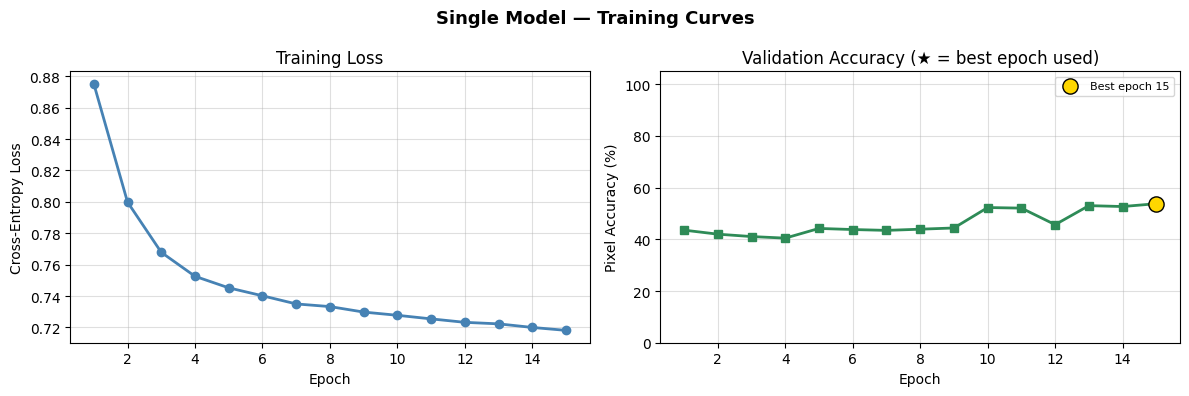

Saved: single_model_curves.png


In [9]:
# CELL 9 — PLOT SINGLE MODEL TRAINING CURVES
# Left : training loss per epoch
# Right: validation accuracy per epoch

epochs_x = list(range(1, len(single_losses) + 1))  # use actual epochs trained (early stopping may stop before EPOCHS)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))
fig.suptitle('Single Model — Training Curves', fontsize=13, fontweight='bold')

ax1.plot(epochs_x, single_losses, marker='o', color='steelblue', linewidth=2)
ax1.set_title('Training Loss')
ax1.set_xlabel('Epoch'); ax1.set_ylabel('Cross-Entropy Loss')
ax1.grid(True, alpha=0.4)

val_pct = [a * 100 for a in single_val_accs]
ax2.plot(epochs_x, val_pct, marker='s', color='seagreen', linewidth=2)
ax2.scatter([single_best_epoch], [val_pct[single_best_epoch - 1]],
            s=120, color='gold', edgecolors='black', zorder=5,
            label=f'Best epoch {single_best_epoch}')
ax2.set_title('Validation Accuracy (★ = best epoch used)')
ax2.set_xlabel('Epoch'); ax2.set_ylabel('Pixel Accuracy (%)')
ax2.set_ylim(0, 105)
ax2.legend(fontsize=8)
ax2.grid(True, alpha=0.4)

plt.tight_layout()
plt.savefig('single_model_curves.png', dpi=150)
plt.show()
print('Saved: single_model_curves.png')


In [10]:
# CELL 10A - TRAIN ENSEMBLE MODELS
# The ensemble is created exactly as required by the project question:
# each neural network varies in hidden-layer count and hidden-node count.
# An odd number of members avoids majority-vote ties.

ENSEMBLE_ARCHS = [
    [3, 8,  NUM_CLASSES],        # M1 — very small, 1 hidden
    [3, 11, NUM_CLASSES],        # M2 — slightly bigger, 1 hidden
    [3, 8,  5,  NUM_CLASSES],    # M3 — two tiny layers
    [3, 12, NUM_CLASSES],        # M4 — still small, 1 hidden
    [3, 5,  4, NUM_CLASSES],    # M5 — two tiny layers, different shape
]

ENSEMBLE_LRS = [LR, LR * 0.7, LR * 1.2, LR * 0.85, LR * 1.1]

ensemble_params_list = []
ens_train_losses_all = []
ens_val_accs_all = []
ens_member_final_accs = []
ens_best_epochs       = []   # best epoch index per member

for i, (arch, member_lr) in enumerate(zip(ENSEMBLE_ARCHS, ENSEMBLE_LRS)):
    torch.manual_seed(SEED + i * 11)
    np.random.seed(SEED + i * 11)

    print(f'\n-- Ensemble Member {i+1}  |  arch: {arch}  |  LR: {member_lr:.5f} --')
    params, t_losses, v_accs, best_ep = train_mlp(
        train_loader, val_loader,
        layer_sizes=arch,
        epochs=EPOCHS, lr=member_lr,
        label=f'Ens-{i+1}'
    )
    ensemble_params_list.append(params)
    ens_train_losses_all.append(t_losses)
    ens_val_accs_all.append(v_accs)
    ens_member_final_accs.append(max(v_accs))   # best accuracy across epochs
    ens_best_epochs.append(best_ep)
    print(f'  -> Member {i+1} best val accuracy: {max(v_accs)*100:.2f}%  (epoch {best_ep})')


torch.manual_seed(SEED)
np.random.seed(SEED)
print('\nAll ensemble members trained.')



-- Ensemble Member 1  |  arch: [3, 8, 7]  |  LR: 0.00150 --
  [Ens-1] Epoch 1/15  |  LR: 0.00150  |  Loss: 0.89535  |  Val Acc: 33.08% * NEW BEST
  [Ens-1] Epoch 2/15  |  LR: 0.00135  |  Loss: 0.78391  |  Val Acc: 53.46% * NEW BEST
  [Ens-1] Epoch 3/15  |  LR: 0.00122  |  Loss: 0.74096  |  Val Acc: 52.71%
  [Ens-1] Epoch 4/15  |  LR: 0.00109  |  Loss: 0.71652  |  Val Acc: 51.18%
  [Ens-1] Epoch 5/15  |  LR: 0.00098  |  Loss: 0.70382  |  Val Acc: 53.54% * NEW BEST
  [Ens-1] Epoch 6/15  |  LR: 0.00089  |  Loss: 0.69808  |  Val Acc: 52.86%
  [Ens-1] Epoch 7/15  |  LR: 0.00080  |  Loss: 0.69194  |  Val Acc: 53.15%
  [Ens-1] Epoch 8/15  |  LR: 0.00072  |  Loss: 0.68974  |  Val Acc: 53.14%
  -> [Ens-1] Early stopping at epoch 9
  -> [Ens-1] Best epoch: 5/15  Val Acc: 53.54%  (restoring these weights)
  -> Member 1 best val accuracy: 53.54%  (epoch 5)

-- Ensemble Member 2  |  arch: [3, 11, 7]  |  LR: 0.00105 --
  [Ens-2] Epoch 1/15  |  LR: 0.00105  |  Loss: 0.81549  |  Val Acc: 54.96% * NEW

In [11]:
# CELL 10B - ENSEMBLE SUMMARY
n_members = len(ENSEMBLE_ARCHS)
print(f'Ensemble size: {n_members} neural networks')
for i, arch in enumerate(ENSEMBLE_ARCHS, 1):
    hidden = arch[1:-1]
    best_ep = ens_best_epochs[i-1]
    print(f'Member {i}: hidden layers={len(hidden)}, hidden nodes={hidden}, best epoch={best_ep}')


Ensemble size: 5 neural networks
Member 1: hidden layers=1, hidden nodes=[8], best epoch=5
Member 2: hidden layers=1, hidden nodes=[11], best epoch=1
Member 3: hidden layers=2, hidden nodes=[8, 5], best epoch=6
Member 4: hidden layers=1, hidden nodes=[12], best epoch=3
Member 5: hidden layers=2, hidden nodes=[5, 4], best epoch=11


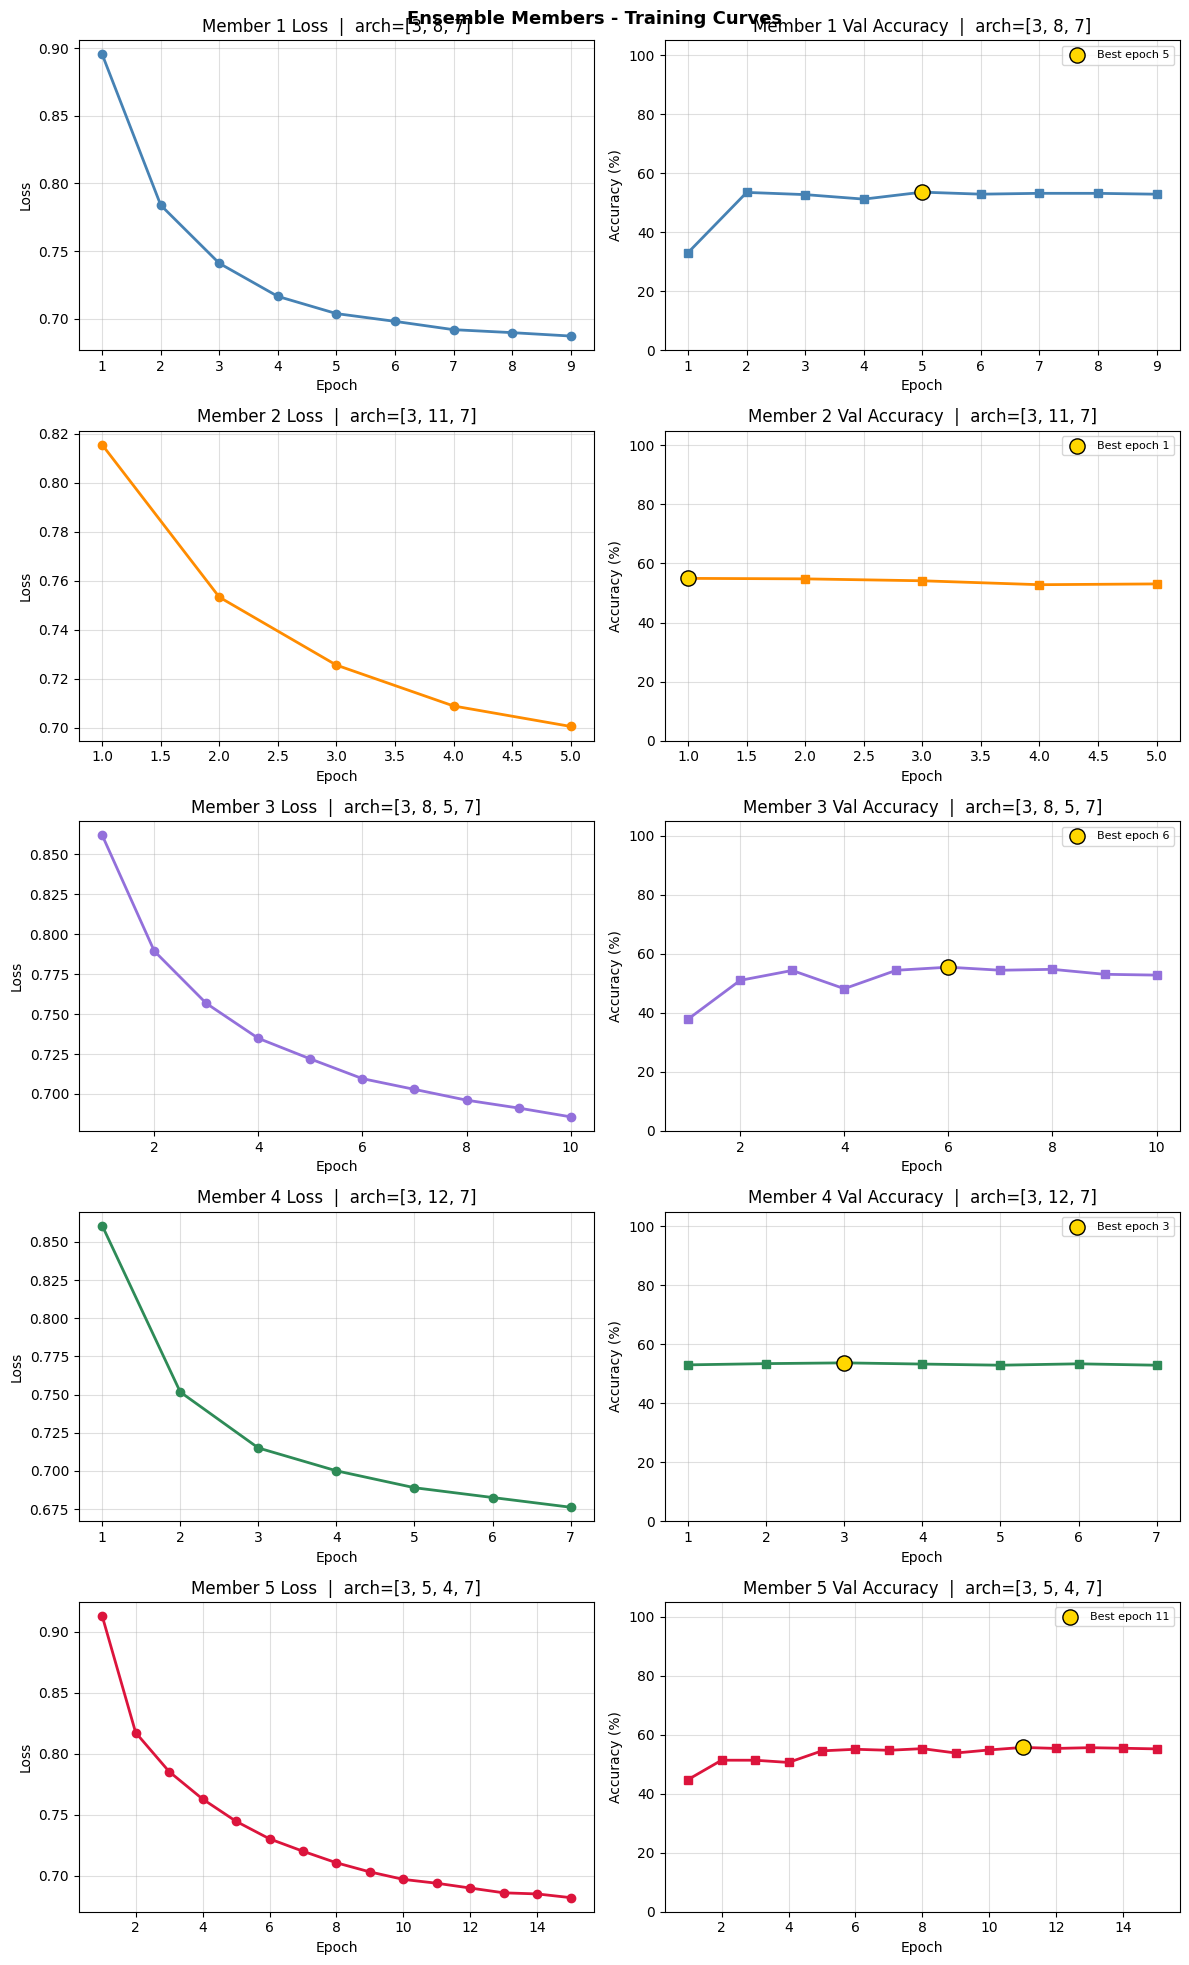

Saved: ensemble_member_curves.png


In [12]:
# CELL 11 - PLOT ENSEMBLE MEMBER TRAINING CURVES
# One row per ensemble member: loss (left) + validation accuracy (right)

n_members = len(ENSEMBLE_ARCHS)
member_colors = ['steelblue', 'darkorange', 'mediumpurple', 'seagreen', 'crimson']

fig, axes = plt.subplots(n_members, 2, figsize=(12, 4 * n_members))
fig.suptitle('Ensemble Members - Training Curves', fontsize=13, fontweight='bold')

for i in range(n_members):
    c = member_colors[i % len(member_colors)]
    arch_str = str(ENSEMBLE_ARCHS[i])
    best_ep  = ens_best_epochs[i]
    val_pct  = [a * 100 for a in ens_val_accs_all[i]]


    member_epochs_x = list(range(1, len(ens_train_losses_all[i]) + 1))  # per-member: handles early stopping
    axes[i, 0].plot(member_epochs_x, ens_train_losses_all[i], marker='o', color=c, linewidth=2)
    axes[i, 0].set_title(f'Member {i+1} Loss  |  arch={arch_str}')
    axes[i, 0].set_xlabel('Epoch')
    axes[i, 0].set_ylabel('Loss')
    axes[i, 0].grid(True, alpha=0.4)

    axes[i, 1].plot(member_epochs_x, val_pct, marker='s', color=c, linewidth=2)
    axes[i, 1].scatter([best_ep], [val_pct[best_ep - 1]],
                       s=120, color='gold', edgecolors='black', zorder=5,
                       label=f'Best epoch {best_ep}')
    axes[i, 1].set_title(f'Member {i+1} Val Accuracy  |  arch={arch_str}')
    axes[i, 1].set_xlabel('Epoch')
    axes[i, 1].set_ylabel('Accuracy (%)')
    axes[i, 1].set_ylim(0, 105)
    axes[i, 1].legend(fontsize=8)
    axes[i, 1].grid(True, alpha=0.4)

plt.tight_layout()
plt.savefig('ensemble_member_curves.png', dpi=150)
plt.show()
print('Saved: ensemble_member_curves.png')


Computing ensemble validation accuracy ...
Ensemble final validation accuracy: 55.10%
Computing held-out test accuracy ...
Single model held-out test accuracy: 64.04%
Ensemble held-out test accuracy    : 65.73%


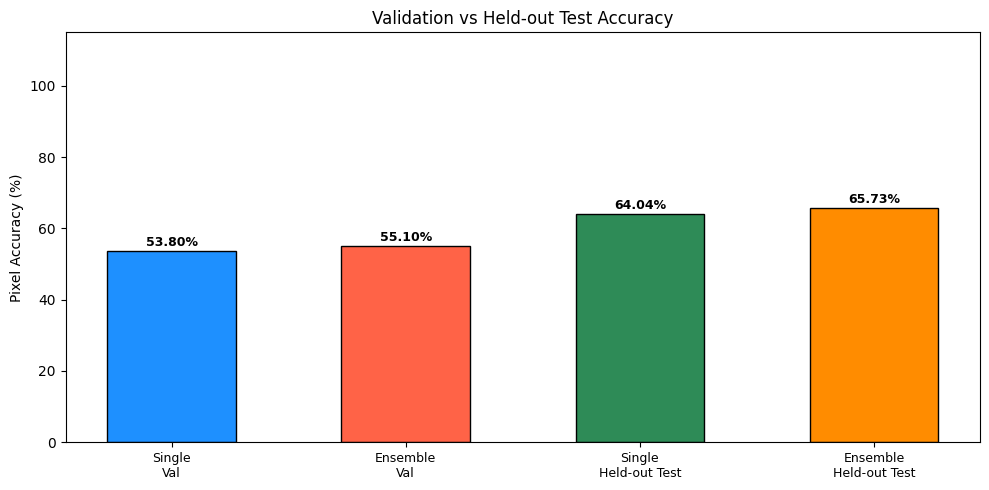

Saved: accuracy_comparison.png


In [13]:
# CELL 12 - ENSEMBLE PREDICT + FINAL VALIDATION / TEST ACCURACY
# Majority vote across all ensemble members.
# Validation is used while developing. Test is held out until final evaluation.

def ensemble_predict(params_list, X):
    """Majority vote over all models in params_list."""
    X = X.to(device)
    preds = []
    for params in params_list:
        with torch.no_grad():
            pred = torch.argmax(forward_logits(X, params), dim=1).cpu()
        preds.append(pred)
    return torch.mode(torch.stack(preds), dim=0).values


def evaluate_ensemble(params_list, loader):
    """Pixel accuracy of the ensemble on the given loader."""
    correct = total = 0
    for X, y in loader:
        X = X.squeeze(0)
        y = y.squeeze(0)
        pred = ensemble_predict(params_list, X)
        correct += (pred == y).sum().item()
        total += y.numel()
    return correct / total


print('Computing ensemble validation accuracy ...')
ensemble_final_acc = evaluate_ensemble(ensemble_params_list, val_loader)
print(f'Ensemble final validation accuracy: {ensemble_final_acc*100:.2f}%')

print('Computing held-out test accuracy ...')
single_test_acc = val_accuracy_single(single_params, test_loader)
ens_test_acc = evaluate_ensemble(ensemble_params_list, test_loader)
print(f'Single model held-out test accuracy: {single_test_acc*100:.2f}%')
print(f'Ensemble held-out test accuracy    : {ens_test_acc*100:.2f}%')

bar_labels = (['Single\nVal', 'Ensemble\nVal']
              + ['Single\nHeld-out Test', 'Ensemble\nHeld-out Test'])

bar_accs = [single_final_val_acc, ensemble_final_acc, single_test_acc, ens_test_acc]
bar_colors = ['dodgerblue', 'tomato', 'seagreen', 'darkorange']

plt.figure(figsize=(10, 5))
bars = plt.bar(bar_labels, [a * 100 for a in bar_accs],
               color=bar_colors, edgecolor='black', width=0.55)

for bar, acc in zip(bars, bar_accs):
    plt.text(bar.get_x() + bar.get_width() / 2,
             bar.get_height() + 0.5,
             f'{acc*100:.2f}%',
             ha='center', va='bottom', fontsize=9, fontweight='bold')

plt.ylim(0, 115)
plt.ylabel('Pixel Accuracy (%)')
plt.title('Validation vs Held-out Test Accuracy')
plt.xticks(fontsize=9)
plt.tight_layout()
plt.savefig('accuracy_comparison.png', dpi=150)
plt.show()
print('Saved: accuracy_comparison.png')


In [14]:
# CELL 13 — SAVE WEIGHTS
# Saves single model, ensemble, and colour maps to .pkl files
# so we can reload later without re-training.

def _detach_params(params):
    return [(W.detach().cpu(), b.detach().cpu()) for W, b in params]


with open('single_model.pkl', 'wb') as f:
    pickle.dump(_detach_params(single_params), f)
print('Saved: single_model.pkl')

with open('ensemble_weights.pkl', 'wb') as f:
    pickle.dump([_detach_params(p) for p in ensemble_params_list], f)
print('Saved: ensemble_weights.pkl')

with open('color_mappings.pkl', 'wb') as f:
    pickle.dump({'color_to_label': color_to_label,
                 'label_to_color': label_to_color}, f)
print('Saved: color_mappings.pkl')

Saved: single_model.pkl
Saved: ensemble_weights.pkl
Saved: color_mappings.pkl


In [15]:
# CELL 14 — HELPER: label map -> RGB image
# Converts a (H, W) integer label array to a visible RGB image.

def labels_to_rgb(label_map, label_to_color):
    """
    label_map     : np.ndarray (H, W) int  OR  torch.Tensor
    label_to_color: dict {int -> (R,G,B)}
    Returns       : np.ndarray (H, W, 3) uint8
    """
    if torch.is_tensor(label_map):
        label_map = label_map.numpy()
    H, W = label_map.shape
    out  = np.zeros((H, W, 3), dtype=np.uint8)
    for lbl, color in label_to_color.items():
        out[label_map == lbl] = color
    return out


print('labels_to_rgb() ready.')

labels_to_rgb() ready.


In [16]:
# CELL 15 — HELPER: accuracy metrics per class
# Given predicted labels and ground-truth labels, computes:
#   Overall Accuracy  (OA)  - pixel accuracy
#   Producer Accuracy (PA)  - recall per class
#   User Accuracy     (UA)  - precision per class
#   Mean IoU          (mIoU)

def compute_accuracy_metrics(pred_flat, gt_flat, num_classes):
    """
    pred_flat, gt_flat : 1-D int arrays or tensors
    Returns a dict with keys:
        overall_accuracy, producer_accuracy, user_accuracy,
        mean_iou, per_class_iou
    """
    if torch.is_tensor(pred_flat): pred_flat = pred_flat.numpy()
    if torch.is_tensor(gt_flat):   gt_flat   = gt_flat.numpy()

    pred_flat = pred_flat.astype(np.int64)
    gt_flat   = gt_flat.astype(np.int64)

    # Build confusion matrix
    cm    = np.zeros((num_classes, num_classes), dtype=np.int64)
    valid = (gt_flat   >= 0) & (gt_flat   < num_classes) \
          & (pred_flat >= 0) & (pred_flat < num_classes)
    np.add.at(cm, (gt_flat[valid], pred_flat[valid]), 1)

    oa = cm.diagonal().sum() / cm.sum() if cm.sum() > 0 else 0.0

    pa, ua, iou = {}, {}, {}
    for c in range(num_classes):
        tp = cm[c, c]
        fn = cm[c, :].sum() - tp
        fp = cm[:, c].sum() - tp
        pa[c]  = tp / (tp + fn) if (tp + fn) > 0 else float('nan')
        ua[c]  = tp / (tp + fp) if (tp + fp) > 0 else float('nan')
        denom  = tp + fp + fn
        iou[c] = tp / denom     if denom > 0       else float('nan')

    valid_ious = [v for v in iou.values() if not np.isnan(v)]
    mean_iou   = float(np.mean(valid_ious)) if valid_ious else float('nan')

    return {'overall_accuracy'  : oa,
            'producer_accuracy' : pa,
            'user_accuracy'     : ua,
            'mean_iou'          : mean_iou,
            'per_class_iou'     : iou}


print('compute_accuracy_metrics() ready.')

compute_accuracy_metrics() ready.


In [17]:
# CELL 16 - TEST IMAGE FUNCTION
#
# test_image(image_path, mask_path)
#
# The function:
#   1. Predicts with the SINGLE model
#   2. Predicts with the ENSEMBLE using majority rule
#   3. Computes OA / PA / UA / mIoU for both vs ground truth
#   4. Shows Input | Ground Truth | Single Pred | Ensemble Pred
#   5. Shows a metric comparison chart and per-class table

def _run_model_on_image(params_list, image_path):
    """Run one or more models on a full image. Returns label map + RGB image."""
    img = np.array(
        Image.open(image_path).convert('RGB').resize(IMAGE_SIZE, Image.BILINEAR)
    ) / 255.0
    H, W, _ = img.shape
    pixels = torch.tensor(img.reshape(-1, 3), dtype=torch.float32)

    preds = []
    for params in params_list:
        with torch.no_grad():
            out = forward_logits(pixels.to(device), params)
        preds.append(torch.argmax(out, dim=1).cpu())

    final = preds[0] if len(preds) == 1 else torch.mode(torch.stack(preds), dim=0).values

    label_map = final.reshape(H, W).numpy()
    color_img = labels_to_rgb(label_map, label_to_color)
    return label_map, color_img


def test_image(image_path, mask_path):
    """Compare Single Model vs Ensemble Majority Vote on one image/mask pair."""
    orig_img = np.array(Image.open(image_path).convert('RGB').resize(IMAGE_SIZE, Image.BILINEAR))

    gt_rgb = np.array(
        Image.open(mask_path).convert('RGB').resize(IMAGE_SIZE, Image.NEAREST)
    )
    gt_t = torch.from_numpy(gt_rgb).long()
    gt_lmap = lut[gt_t[..., 0], gt_t[..., 1], gt_t[..., 2]].numpy()
    gt_flat = gt_lmap.flatten()
    gt_vis = labels_to_rgb(gt_lmap, label_to_color)

    single_label_map, single_color = _run_model_on_image([single_params], image_path)
    ens_label_map, ens_color = _run_model_on_image(ensemble_params_list, image_path)

    valid = gt_flat >= 0
    single_m = compute_accuracy_metrics(single_label_map.flatten()[valid], gt_flat[valid], NUM_CLASSES)
    ens_m = compute_accuracy_metrics(ens_label_map.flatten()[valid], gt_flat[valid], NUM_CLASSES)

    fig, axes = plt.subplots(1, 4, figsize=(20, 5))
    fig.suptitle('Single Neural Network vs Ensemble Majority Rule',
                 fontsize=13, fontweight='bold')

    for ax, title, im in zip(
        axes,
        ['Input Image', 'Ground Truth', 'Single Model', 'Ensemble Majority Vote'],
        [orig_img, gt_vis, single_color, ens_color]
    ):
        ax.imshow(im)
        ax.set_title(title, fontsize=11, fontweight='bold')
        ax.axis('off')

    plt.tight_layout()
    plt.savefig('test_image_comparison.png', dpi=150)
    plt.show()
    print('Saved: test_image_comparison.png')

    metric_names = ['Overall Accuracy', 'Mean IoU']
    single_vals = [
        single_m['overall_accuracy'] * 100,
        single_m['mean_iou'] * 100 if not np.isnan(single_m['mean_iou']) else 0
    ]
    ens_vals = [
        ens_m['overall_accuracy'] * 100,
        ens_m['mean_iou'] * 100 if not np.isnan(ens_m['mean_iou']) else 0
    ]

    x = np.arange(len(metric_names))
    width = 0.3
    fig2, ax = plt.subplots(figsize=(7, 5))
    bars1 = ax.bar(x - width/2, single_vals, width, label='Single Model',
                   color='steelblue', edgecolor='black')
    bars2 = ax.bar(x + width/2, ens_vals, width, label='Ensemble Majority Vote',
                   color='tomato', edgecolor='black')

    for bar in list(bars1) + list(bars2):
        ax.text(bar.get_x() + bar.get_width() / 2,
                bar.get_height() + 0.5,
                f'{bar.get_height():.1f}%',
                ha='center', va='bottom', fontsize=9)

    ax.set_xticks(x)
    ax.set_xticklabels(metric_names)
    ax.set_ylim(0, 115)
    ax.set_ylabel('Score (%)')
    ax.set_title('Single vs Ensemble - Test Image Metrics')
    ax.legend()
    ax.grid(True, axis='y', alpha=0.4)
    plt.tight_layout()
    plt.savefig('test_image_metrics_bar.png', dpi=150)
    plt.show()
    print('Saved: test_image_metrics_bar.png')

    print('\n' + '=' * 60)
    print(f'{"METRIC":<32} {"SINGLE":>12}  {"ENSEMBLE":>12}')
    print('=' * 60)
    print(f'{"Overall Accuracy":<32} '
          f'{single_m["overall_accuracy"]*100:>11.2f}%  '
          f'{ens_m["overall_accuracy"]*100:>11.2f}%')
    mi_s = single_m['mean_iou']
    mi_e = ens_m['mean_iou']
    print(f'{"Mean IoU":<32} '
          f'{mi_s*100 if not np.isnan(mi_s) else 0:>11.2f}%  '
          f'{mi_e*100 if not np.isnan(mi_e) else 0:>11.2f}%')

    present = sorted(set(gt_flat[valid].astype(int)))
    print('\n' + '-' * 60)
    print(f'{"Cls":<5} {"PA-Single":>10} {"PA-Ens":>10}  '
          f'{"UA-Single":>10} {"UA-Ens":>10}')
    print('  PA = Producer Accuracy (Recall)  |  UA = User Accuracy (Precision)')
    print('-' * 60)

    def _f(v):
        return f'{v*100:>9.2f}%' if not np.isnan(v) else '      N/A'

    for c in present:
        pa_s = single_m['producer_accuracy'].get(c, float('nan'))
        pa_e = ens_m['producer_accuracy'].get(c, float('nan'))
        ua_s = single_m['user_accuracy'].get(c, float('nan'))
        ua_e = ens_m['user_accuracy'].get(c, float('nan'))
        print(f'{c:<5} {_f(pa_s)} {_f(pa_e)}  {_f(ua_s)} {_f(ua_e)}')

    print('=' * 60)


print('test_image() ready.')


test_image() ready.


In [18]:
# CELL 16B - FULL HELD-OUT TEST SET ACCURACY
# This evaluates every image in test_loader, not only one selected image.

def evaluate_single_model(params, loader):
    """Pixel accuracy of the single model on a full DataLoader."""
    correct = total = 0
    for X, y in loader:
        X = X.squeeze(0).to(device)
        y = y.squeeze(0).to(device)
        with torch.no_grad():
            pred = torch.argmax(forward_logits(X, params), dim=1)
        correct += (pred == y).sum().item()
        total += y.numel()
    return correct / total if total > 0 else 0.0


def evaluate_single_and_ensemble_on_test_set():
    """Report final accuracy on all held-out test images."""
    single_acc = evaluate_single_model(single_params, test_loader)
    ensemble_acc = evaluate_ensemble(ensemble_params_list, test_loader)

    print('\n' + '=' * 60)
    print('FINAL HELD-OUT TEST SET ACCURACY')
    print('=' * 60)
    print(f'Test images evaluated            : {len(test_pairs)}')
    print(f'Single model test accuracy       : {single_acc * 100:.2f}%')
    print(f'Ensemble majority test accuracy  : {ensemble_acc * 100:.2f}%')
    print('=' * 60)

    return single_acc, ensemble_acc


single_test_acc, ensemble_test_acc = evaluate_single_and_ensemble_on_test_set()



FINAL HELD-OUT TEST SET ACCURACY
Test images evaluated            : 20
Single model test accuracy       : 64.04%
Ensemble majority test accuracy  : 65.73%


Testing unknown image: /kaggle/working/heldout_test_split/images/image0154.jpg


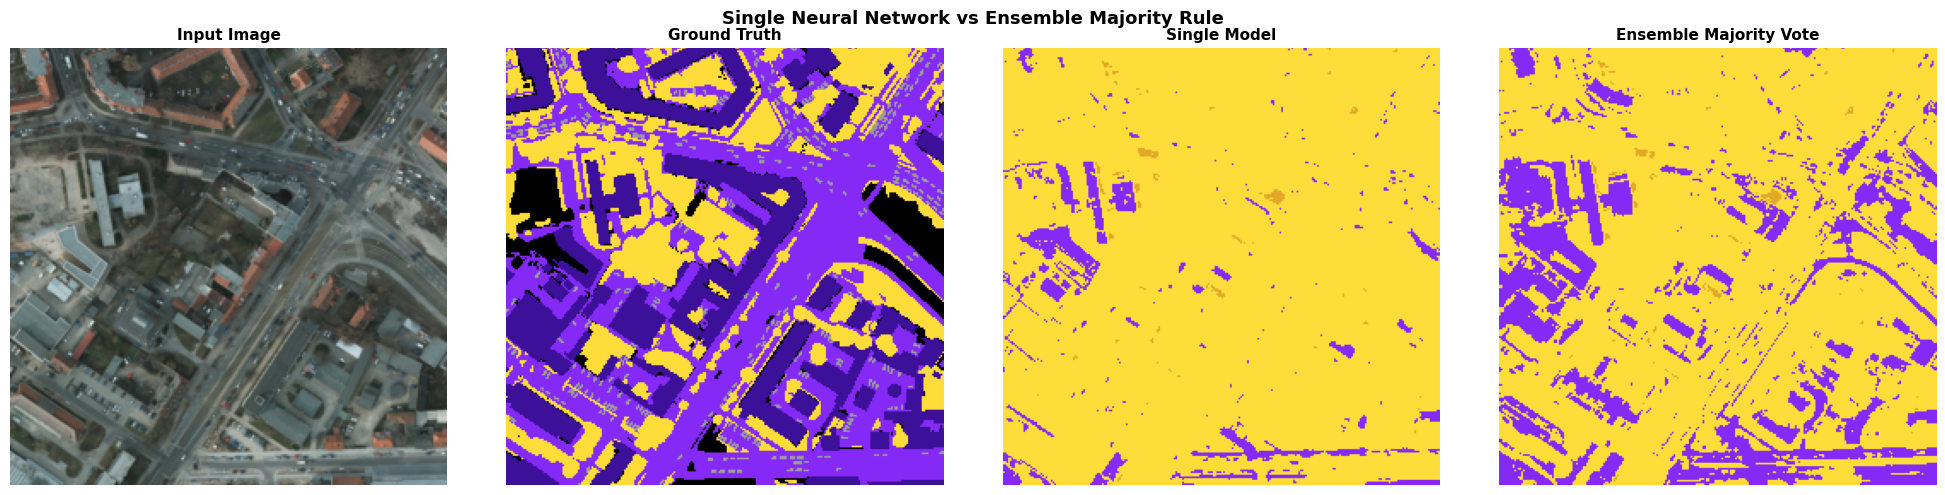

Saved: test_image_comparison.png


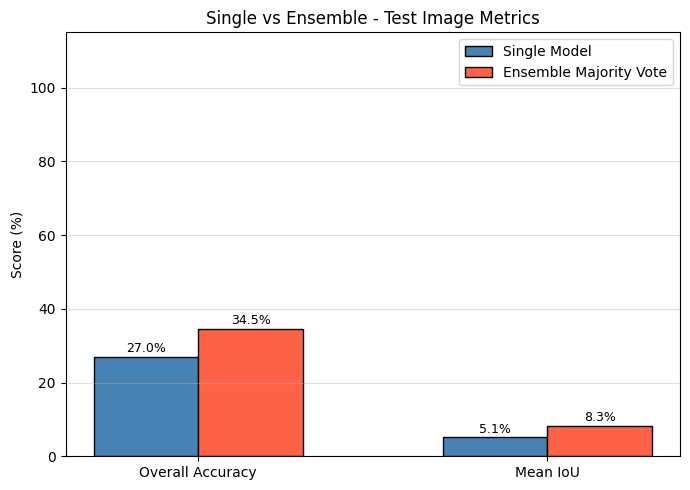

Saved: test_image_metrics_bar.png

METRIC                                 SINGLE      ENSEMBLE
Overall Accuracy                       27.04%        34.51%
Mean IoU                                5.11%         8.31%

------------------------------------------------------------
Cls    PA-Single     PA-Ens   UA-Single     UA-Ens
  PA = Producer Accuracy (Recall)  |  UA = User Accuracy (Precision)
------------------------------------------------------------
0          0.00%      0.00%        N/A       N/A
2          4.09%     23.32%      28.93%     43.14%
3          0.00%      0.00%        N/A       N/A
5         98.25%     97.47%      27.07%     32.32%
6          0.00%      0.00%        N/A       N/A


In [19]:
# CELL 17 - RUN test_image() ON A HELD-OUT TEST IMAGE
# This image/mask pair comes from test_pairs, so it was not used for training.

test_pair = test_pairs[0]

TEST_IMAGE_PATH = os.path.join(TEST_IMAGE_DIR, test_pair['image_file'])
TEST_MASK_PATH  = os.path.join(TEST_MASK_DIR,  test_pair['mask_file'])

print('Testing unknown image:', TEST_IMAGE_PATH)
test_image(TEST_IMAGE_PATH, TEST_MASK_PATH)


Testing unknown image: /kaggle/working/heldout_test_split/images/image0027.jpg


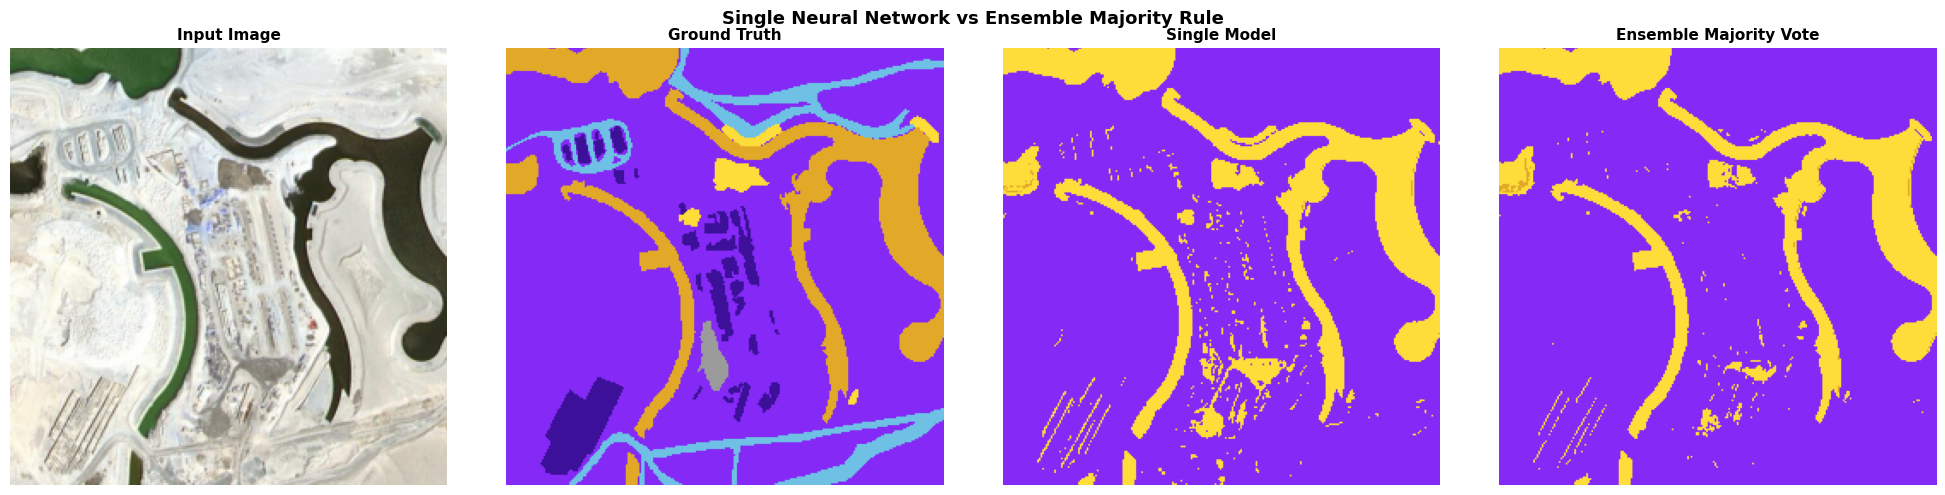

Saved: test_image_comparison.png


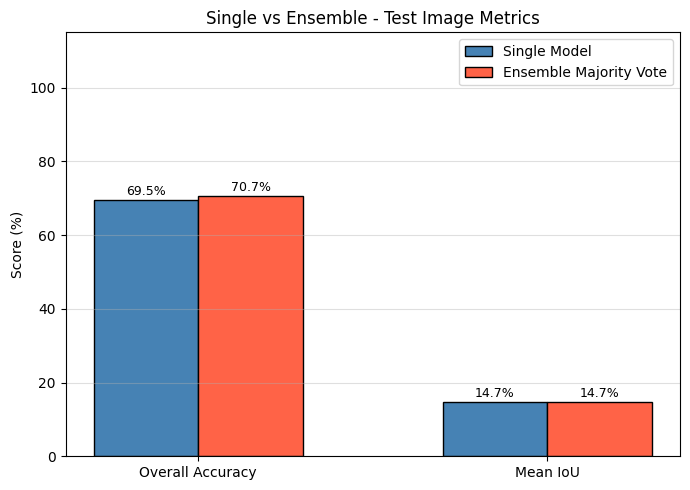

Saved: test_image_metrics_bar.png

METRIC                                 SINGLE      ENSEMBLE
Overall Accuracy                       69.55%        70.71%
Mean IoU                               14.70%        14.66%

------------------------------------------------------------
Cls    PA-Single     PA-Ens   UA-Single     UA-Ens
  PA = Producer Accuracy (Recall)  |  UA = User Accuracy (Precision)
------------------------------------------------------------
0          0.00%      0.00%        N/A       N/A
1          0.00%      0.00%        N/A       N/A
2         96.12%     98.16%      84.91%     83.99%
3          0.00%      0.00%        N/A       N/A
4          0.60%      1.43%     100.00%    100.00%
5         80.07%     49.15%       5.57%      3.98%


In [20]:
# CELL 18 - RUN test_image() ON ANOTHER HELD-OUT TEST IMAGE
# Change TEST_INDEX to select any other image from the held-out test set.

TEST_INDEX = 1 if len(test_pairs) > 1 else 0
test_pair = test_pairs[TEST_INDEX]

TEST_IMAGE_PATH = os.path.join(TEST_IMAGE_DIR, test_pair['image_file'])
TEST_MASK_PATH  = os.path.join(TEST_MASK_DIR,  test_pair['mask_file'])

print('Testing unknown image:', TEST_IMAGE_PATH)
test_image(TEST_IMAGE_PATH, TEST_MASK_PATH)
